<a href="https://colab.research.google.com/github/aansheeagrwal/python-training/blob/main/GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generative Adversarial Network:

They are type of deep learning model that is used to generate new, synthetic data that is similar to real data (just like image,music,text,video).

It has two neural networks :
1. Genrator
2. Discriminator

Genrator : It is used to create fake data that is so realistic that it can fool the discriminator into thinking its real

Discriminator : It is to tell us the difference between real and fake.

Workflow of GAN's:
1. Input random noise into the genrator
2. Genrate and produce fake image
3. Fake image and a real image are passed to the discriminator
4. Discriminator try to guess which one is real
5. Genrator update to improve how real the fake looks
6. Discriminator to update better detect fake
7. The compition continues until the fake image becomes realistic in a better discriminator cannot tell the difference

Workflow of Generator:
1. Input
2.Processing : pass the input data through a series of layers
(Dense layer,Conv transpose,batch norms)
3.Output

Workflow of Discriminator:
1. Real or fake image
2. Discriminator
3. Classify input as real or fake

In [ ]:
#Genrator --
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Reshape,BatchNormalization,LeakyReLU,Conv2DTranspose,Conv2D,Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
import numpy as np

In [ ]:
#load dataset --
(X_train,_),(X_test,_)=mnist.load_data()
X_train =(X_train -127.5)/127.5 #normalize [-1,1]
X_train = np.expand_dims(X_train,axis=-1)
print(X_train.shape)

datasize = 60000
batch_size = 128
latent_dim = 100

data = tf.data.Dataset.from_tensor_slices(X_train[:datasize]).batch(batch_size)

def generator():
    model=Sequential()
    # fully connected layers--
    model.add(Dense(128*7*7,input_shape=(latent_dim,))) # Added input_shape
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())
    model.add(Reshape((7,7,128)))

    # sample1----
    model.add(Conv2DTranspose(128,kernel_size=4,strides=2,padding="same"))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    # sample2 ---
    model.add(Conv2DTranspose(128,kernel_size=4,strides=2,padding="same"))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    # final layer--
    model.add(Conv2DTranspose(1,kernel_size=3,strides=1,padding="same",activation='tanh'))
    return model

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


In [ ]:
print(data)

<_BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float64, name=None)>


In [ ]:
Generators = generator()
Generators.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185,281 (4.52 MB)

 Trainable params: 1,172,225 (4.47 MB)

 Non-trainable params: 13,056 (51.00 KB)

In [ ]:
print(Generators.input_shape)
print(Generators.output_shape)

(None, 100)
(None, 28, 28, 1)


In [ ]:
import matplotlib.pyplot as plt
input = np.random.normal(0,1,(1,100))
output = Generators.predict(input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


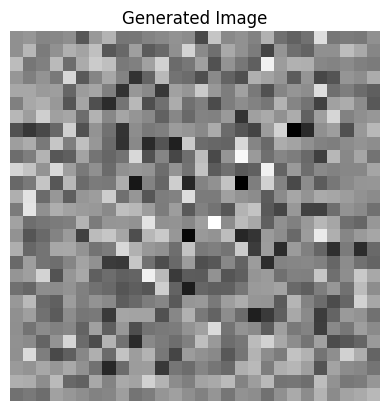

In [ ]:
output1 = (output+1)/2.0
plt.imshow(output1[0,:,:,0],cmap = "grey")
plt.title("Generated Image")
plt.axis("off")
plt.show()

In [ ]:
#Discriminator --
def discriminator():
  model = Sequential([
      Conv2D(64,kernel_size=3,strides=2,padding="same"),
      LeakyReLU(alpha=0.2),
      Conv2D(128,kernel_size=3,strides=2,padding="same"),
      LeakyReLU(alpha=0.2),
      Flatten(),
      Dense(1,activation="sigmoid")
  ])
  return model

In [ ]:
Discriminators = discriminator()
Discriminators.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Loss and optimizers --
cross_entropy = tf.keras.losses.BinaryCrossentropy()
generator_optimizer = tf.keras.optimizers.Adam(1e-4) #0.0001
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
print(cross_entropy)

<LossFunctionWrapper(<function binary_crossentropy at 0x7a4a8afc00e0>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>


In [ ]:
#1e-3 : fast learning
#1e-4: slow learning and scalable
#1e-5: very slow

In [ ]:
#Gradient Tape is the method to diffrentiate between real and fake

In [ ]:
#Training step --
@tf.function
def training(real_image):
  #genreate random noise input from generator
  input = tf.random.normal([batch_size,latent_dim])
  #start tracking gradients
  with tf.GradientTape() as disc_tape, tf.GradientTape() as gen_tape:
    #Genrate fake image
    fake_image = Generators(input,training=True)
    #get discriminators outputs
    real_output = Discriminators(real_image,training=True)
    fake_output = Discriminators(fake_image,training=True)
    #calculate duscriminators outputs
    disc_loss_real = cross_entropy(tf.ones_like(real_output),real_output)
    disc_loss_fake = cross_entropy(tf.zeros_like(fake_output),fake_output)
    disc_loss = disc_loss_real + disc_loss_fake
    #calculate generator loss
    gen_loss = cross_entropy(tf.ones_like(fake_output),fake_output)

  #compute the gradient --
  gradients_of_dis = disc_tape.gradient(disc_loss,Discriminators.trainable_variables)
  gradients_of_gen = gen_tape.gradient(gen_loss,Generators.trainable_variables)

  #apply optimizer --
  discriminator_optimizer.apply_gradients(zip(gradients_of_dis,Discriminators.trainable_variables))
  generator_optimizer.apply_gradients(zip(gradients_of_gen,Generators.trainable_variables))
  return disc_loss,gen_loss

In [ ]:
#genrate images
def genrate_image(model,epoch):
  input = np.random.normal(size=(1,latent_dim))
  output = model(input,training=False)
  image = (output[0,:,:,0]+1)/2.0
  plt.imshow(image,cmap = "grey")
  plt.title(f"Generated Image,{epoch}")
  plt.axis("off")
  plt.show()
  print(input.shape)

In [ ]:
#training loop
def train(data,epochs=50):
  for epoch in range(1,epochs+1):
    for i in data:
      disc_loss,gen_loss = training(i)
    print(f"Epoch: {epoch}, Discriminator Loss: {disc_loss}, Generator Loss: {gen_loss}")
    if epoch % 5 == 0 or epoch == 1:
      genrate_image(Generators,epoch)

In [ ]:
for image_batch in data.take(1):
  print(image_batch.shape)

(128, 28, 28, 1)


Epoch: 1, Discriminator Loss: 1.2094249725341797, Generator Loss: 0.8391327261924744


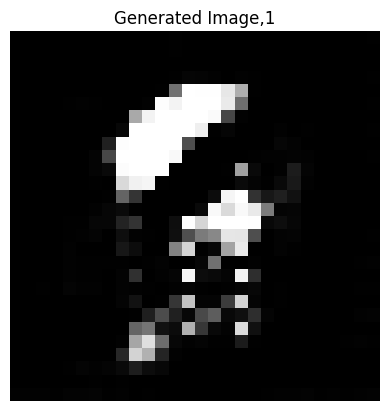

(1, 100)
Epoch: 2, Discriminator Loss: 1.718855857849121, Generator Loss: 0.6638287901878357
Epoch: 3, Discriminator Loss: 1.469163179397583, Generator Loss: 0.7614535689353943
Epoch: 4, Discriminator Loss: 1.4413889646530151, Generator Loss: 0.8757165670394897
Epoch: 5, Discriminator Loss: 1.3831510543823242, Generator Loss: 0.6767970323562622


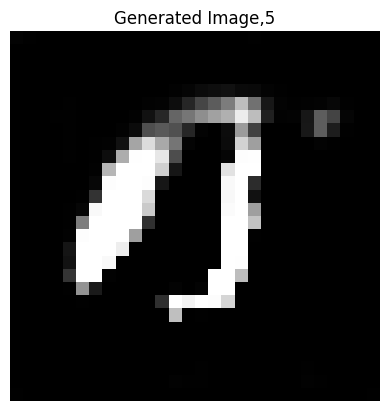

(1, 100)
Epoch: 6, Discriminator Loss: 1.4529320001602173, Generator Loss: 0.7952543497085571
Epoch: 7, Discriminator Loss: 1.2431613206863403, Generator Loss: 0.802599310874939
Epoch: 8, Discriminator Loss: 1.2595787048339844, Generator Loss: 0.8141403198242188
Epoch: 9, Discriminator Loss: 1.1266573667526245, Generator Loss: 0.8663826584815979
Epoch: 10, Discriminator Loss: 1.4596219062805176, Generator Loss: 0.7605723738670349


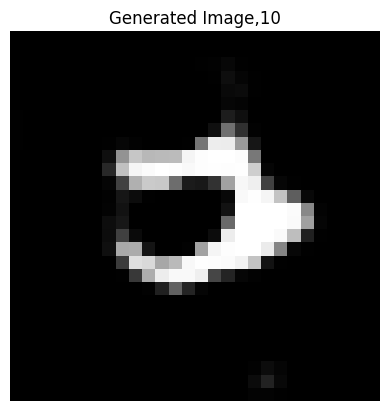

(1, 100)
Epoch: 11, Discriminator Loss: 1.3713970184326172, Generator Loss: 0.773469090461731
Epoch: 12, Discriminator Loss: 1.2441933155059814, Generator Loss: 0.7871845960617065
Epoch: 13, Discriminator Loss: 1.349276065826416, Generator Loss: 0.7091659307479858
Epoch: 14, Discriminator Loss: 1.3837146759033203, Generator Loss: 0.7506707906723022
Epoch: 15, Discriminator Loss: 1.3643690347671509, Generator Loss: 0.7400276064872742


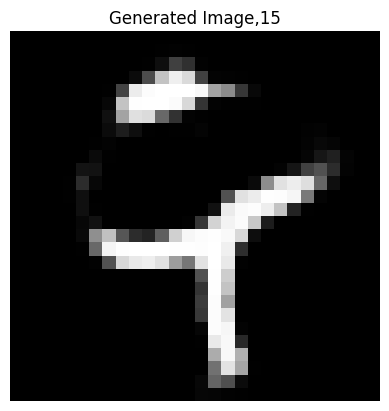

(1, 100)
Epoch: 16, Discriminator Loss: 1.3641835451126099, Generator Loss: 0.6955239176750183
Epoch: 17, Discriminator Loss: 1.408902883529663, Generator Loss: 0.6890512108802795
Epoch: 18, Discriminator Loss: 1.2491393089294434, Generator Loss: 0.7291409373283386
Epoch: 19, Discriminator Loss: 1.4454265832901, Generator Loss: 0.6793651580810547
Epoch: 20, Discriminator Loss: 1.267896294593811, Generator Loss: 0.7660144567489624


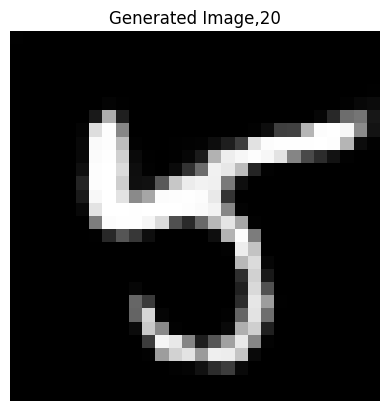

(1, 100)
Epoch: 21, Discriminator Loss: 1.3584084510803223, Generator Loss: 0.7488530278205872
Epoch: 22, Discriminator Loss: 1.3811047077178955, Generator Loss: 0.6555198431015015
Epoch: 23, Discriminator Loss: 1.3748693466186523, Generator Loss: 0.7350952625274658
Epoch: 24, Discriminator Loss: 1.3357915878295898, Generator Loss: 0.7501785159111023
Epoch: 25, Discriminator Loss: 1.438057541847229, Generator Loss: 0.6561633348464966


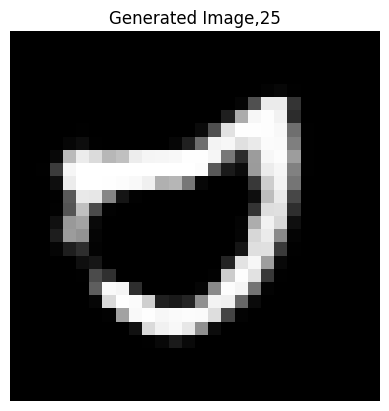

(1, 100)
Epoch: 26, Discriminator Loss: 1.2887192964553833, Generator Loss: 0.7630064487457275
Epoch: 27, Discriminator Loss: 1.2568119764328003, Generator Loss: 0.7393171787261963
Epoch: 28, Discriminator Loss: 1.3718891143798828, Generator Loss: 0.7113662958145142
Epoch: 29, Discriminator Loss: 1.4044947624206543, Generator Loss: 0.6523315906524658
Epoch: 30, Discriminator Loss: 1.3686622381210327, Generator Loss: 0.6562378406524658


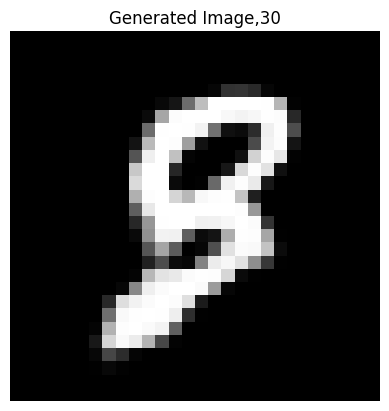

(1, 100)
Epoch: 31, Discriminator Loss: 1.4088200330734253, Generator Loss: 0.7286849617958069
Epoch: 32, Discriminator Loss: 1.416386604309082, Generator Loss: 0.7243379354476929
Epoch: 33, Discriminator Loss: 1.4426106214523315, Generator Loss: 0.6590802073478699
Epoch: 34, Discriminator Loss: 1.3281676769256592, Generator Loss: 0.7629662752151489
Epoch: 35, Discriminator Loss: 1.4638714790344238, Generator Loss: 0.7373026609420776


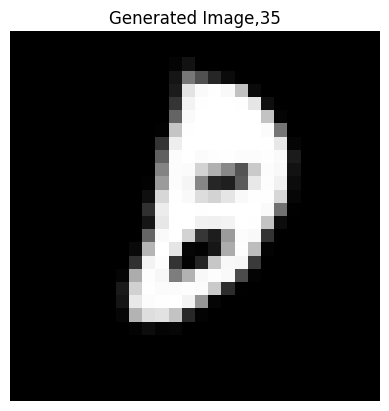

(1, 100)
Epoch: 36, Discriminator Loss: 1.5016379356384277, Generator Loss: 0.6433557868003845
Epoch: 37, Discriminator Loss: 1.4220750331878662, Generator Loss: 0.7375403642654419


In [ ]:
train(data,epochs = 50)